# Generation Lab — Faces with a Diffusion Model

**MS2A — Machine Learning Practice · Session 7, Computer Vision 2**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/racousin/data_science_practice/blob/main/website/public/modules/ms2a-machine-learning-practice/challenges/mlp-s7-diffusion-faces.ipynb)

The same task as the GAN notebook — CelebA faces — with the other family
of the *Diffusion Models* lesson. No discriminator, no adversarial game: a
U-Net learns to predict the noise that was added to an image, and
generation is that denoising repeated from pure noise.

| Part | What you do | Time on a T4 |
|---|---|---|
| 1–2 | load the faces, watch the forward (noising) process | 2 min |
| 3–4 | train a small DDPM **from scratch** at 32 × 32, sample with DDPM and DDIM | 12 min |
| 5 | **fine-tune** a pretrained CIFAR-10 DDPM on the faces, same budget | 8 min |
| 6 | sample a large **pretrained** CelebA-HQ model at 256 × 256 | 2 min |
| 7 | interpolate in noise space — the counterpart of the GAN's latent walk | 1 min |

> In Colab: **Runtime → Change runtime type → T4 GPU**, then run the cells top to
> bottom. Every budget is in the *Configuration* cell: lower it on a CPU.

Companion notebook, the GAN: [mlp-s7-gan-faces.ipynb](https://colab.research.google.com/github/racousin/data_science_practice/blob/main/website/public/modules/ms2a-machine-learning-practice/challenges/mlp-s7-gan-faces.ipynb).

## Setup

In [1]:
!pip install -q diffusers datasets

import math, time
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision.transforms as T
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
from datasets import load_dataset
from diffusers import UNet2DModel, DDPMScheduler, DDIMScheduler, DDIMPipeline
from tqdm.auto import tqdm

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device)
torch.manual_seed(0)

device: cuda


### Configuration

In [2]:
N_IMAGES = 30_000      # CelebA faces used for training (same subset as the GAN)
IMAGE_SIZE = 32        # 32 x 32: a diffusion U-Net at 64 x 64 needs hours, not minutes
BATCH_SIZE = 128
TRAIN_STEPS = 3_000    # Part 3, from scratch
FINETUNE_STEPS = 1_500 # Part 5, from the CIFAR-10 model
SAMPLE_STEPS = 50      # DDIM steps when sampling

In [3]:
def show(images, title='', nrow=8, size=8):
    """images in [-1, 1], shape (B, 3, H, W)."""
    grid = make_grid(images.detach().cpu().clamp(-1, 1), nrow=nrow,
                     normalize=True, value_range=(-1, 1))
    plt.figure(figsize=(size, size * grid.shape[1] / grid.shape[2]))
    plt.imshow(grid.permute(1, 2, 0)); plt.axis('off'); plt.title(title)
    plt.show()

---

# Part 1: The faces

The CelebA subset of the GAN notebook, resized to 32 × 32 and scaled to
[-1, 1] — the range of the Gaussian noise the model will add to it.

dataset_infos.json:   0%|          | 0.00/667 [00:00<?, ?B/s]

data/train-00000-of-00003.parquet: reconstructing file:   0%|          |  0.00B /  462MB            

data/train-00000-of-00003.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/202599 [00:00<?, ? examples/s]

decode:   0%|          | 0/30000 [00:00<?, ?it/s]

batch: (128, 3, 32, 32) range: -1.0 1.0


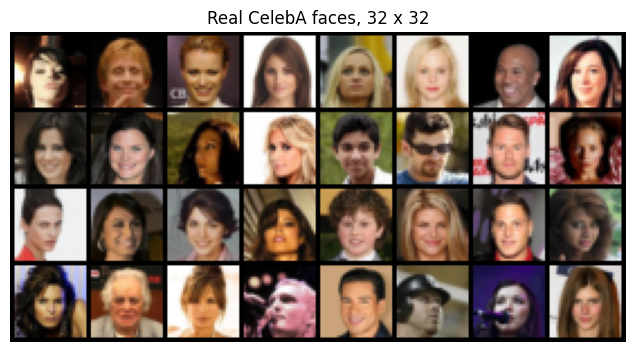

In [4]:
tf = T.Compose([T.Resize(IMAGE_SIZE), T.CenterCrop(IMAGE_SIZE),
                T.ToTensor(), T.Normalize([0.5] * 3, [0.5] * 3)])

# The first of the three parquet shards: 67k faces, 460 MB instead of 1.4 GB.
faces = load_dataset('nielsr/CelebA-faces', data_files='data/train-00000-of-00003.parquet',
                     split=f'train[:{N_IMAGES}]',
                     verification_mode='no_checks')  # its recorded size is the 3 shards'
# Decode once: 30k faces at 32 x 32 are 92 MB in memory, and training never
# waits for JPEG decoding again.
data = torch.stack([tf(im.convert('RGB')) for im in tqdm(faces['image'], desc='decode')])
loader = DataLoader(data, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

batch = next(iter(loader))
print('batch:', tuple(batch.shape), 'range:', batch.min().item(), batch.max().item())
show(batch[:32], 'Real CelebA faces, 32 x 32')

---

# Part 2: The forward process

Noise is added in $T = 1000$ small steps. With $\bar\alpha_t = \prod_{s \le t} (1 - \beta_s)$,
any step can be reached in one jump:

$$x_t = \sqrt{\bar\alpha_t}\, x_0 + \sqrt{1 - \bar\alpha_t}\, \varepsilon, \qquad \varepsilon \sim \mathcal N(0, I)$$

Nothing here is learnt: the scheduler is a fixed table of $\beta_t$.

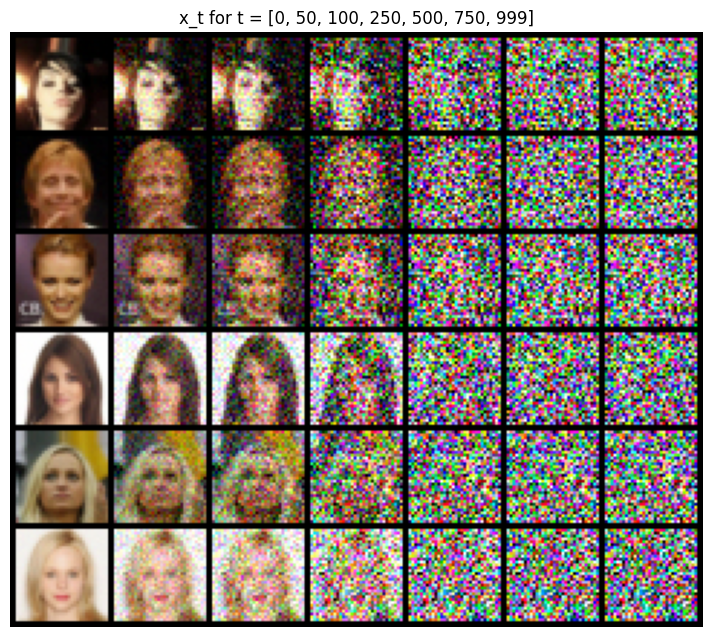

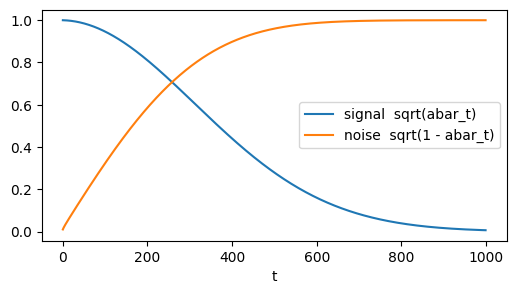

In [5]:
scheduler = DDPMScheduler(num_train_timesteps=1000)   # linear betas, 1e-4 -> 0.02

x0 = batch[:6]
ts = [0, 50, 100, 250, 500, 750, 999]
noise = torch.randn_like(x0)
rows = [scheduler.add_noise(x0, noise, torch.full((6,), t)) for t in ts]
show(torch.stack(rows, 1).flatten(0, 1), f'x_t for t = {ts}', nrow=len(ts), size=9)

abar = scheduler.alphas_cumprod
plt.figure(figsize=(6, 3)); plt.plot(abar.sqrt(), label='signal  sqrt(abar_t)')
plt.plot((1 - abar).sqrt(), label='noise  sqrt(1 - abar_t)'); plt.xlabel('t')
plt.legend(); plt.show()

### Question 1

1. At which $t$ can you no longer tell there was a face? What is $\bar\alpha_{999}$?
2. Why must the images be in $[-1, 1]$ and not $[0, 255]$?

---

# Part 3: Train a DDPM from scratch

The model is a U-Net $\varepsilon_\theta(x_t, t)$: input a noisy image and its
timestep, output the noise. The loss is a plain regression:

$$\mathcal L = \mathbb E_{x_0, t, \varepsilon} \big\lVert \varepsilon - \varepsilon_\theta(x_t, t) \big\rVert^2$$

The U-Net is the segmentation architecture of this session, with the
timestep embedded and added inside every residual block, and self-attention
at the 8 × 8 resolution.

In [6]:
def small_unet():
    return UNet2DModel(
        sample_size=IMAGE_SIZE, in_channels=3, out_channels=3,
        block_out_channels=(64, 128, 256), layers_per_block=2,
        down_block_types=('DownBlock2D', 'DownBlock2D', 'AttnDownBlock2D'),
        up_block_types=('AttnUpBlock2D', 'UpBlock2D', 'UpBlock2D'),
    )

model = small_unet().to(device)
print(f'parameters: {sum(p.numel() for p in model.parameters()):,}')

parameters: 15,724,931


  0%|          | 0/3000 [00:00<?, ?it/s]

3000 steps in 14.2 min


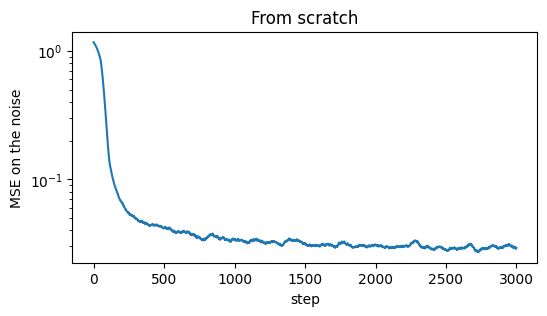

In [7]:
def train(model, steps, lr):
    opt = torch.optim.AdamW(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=lr, total_steps=steps, pct_start=0.05)
    scaler = torch.amp.GradScaler(enabled=device == 'cuda')
    losses, it, model = [], iter(loader), model.train()
    for step in tqdm(range(steps)):
        try:
            x0 = next(it)
        except StopIteration:
            it = iter(loader); x0 = next(it)
        x0 = x0.to(device)
        flip = torch.rand(x0.size(0), 1, 1, 1, device=device) < 0.5   # augmentation
        x0 = torch.where(flip, x0.flip(3), x0)
        eps = torch.randn_like(x0)
        t = torch.randint(0, scheduler.config.num_train_timesteps, (x0.size(0),), device=device)
        xt = scheduler.add_noise(x0, eps, t)
        with torch.autocast(device, dtype=torch.float16, enabled=device == 'cuda'):
            loss = F.mse_loss(model(xt, t).sample, eps)
        opt.zero_grad(set_to_none=True)
        scaler.scale(loss).backward()
        scaler.unscale_(opt); torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(opt); scaler.update(); sched.step()
        losses.append(loss.item())
    return losses

start = time.time()
losses_scratch = train(model, TRAIN_STEPS, lr=2e-4)
print(f'{TRAIN_STEPS} steps in {(time.time() - start) / 60:.1f} min')

smooth = lambda l, k=50: [sum(l[max(0, i - k):i + 1]) / len(l[max(0, i - k):i + 1]) for i in range(len(l))]
plt.figure(figsize=(6, 3)); plt.plot(smooth(losses_scratch)); plt.yscale('log')
plt.xlabel('step'); plt.ylabel('MSE on the noise'); plt.title('From scratch'); plt.show()

### Question 2

1. Compare this loss curve with the GAN's two curves. Which one tells you
   whether training is going well?
2. The loss averages over $t$. Is predicting the noise harder at $t = 10$ or
   at $t = 900$? (Try it: evaluate the loss at fixed $t$ on one batch.)

---

# Part 4: Sampling — DDPM and DDIM

**DDPM** runs the 1000 reverse steps, each adding a little fresh noise.
**DDIM** reuses the same trained model on a coarser, deterministic path:
50 steps instead of 1000, same network, no retraining.

  0%|          | 0/50 [00:00<?, ?it/s]

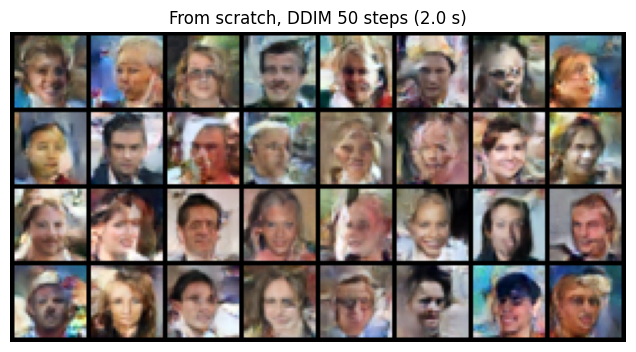

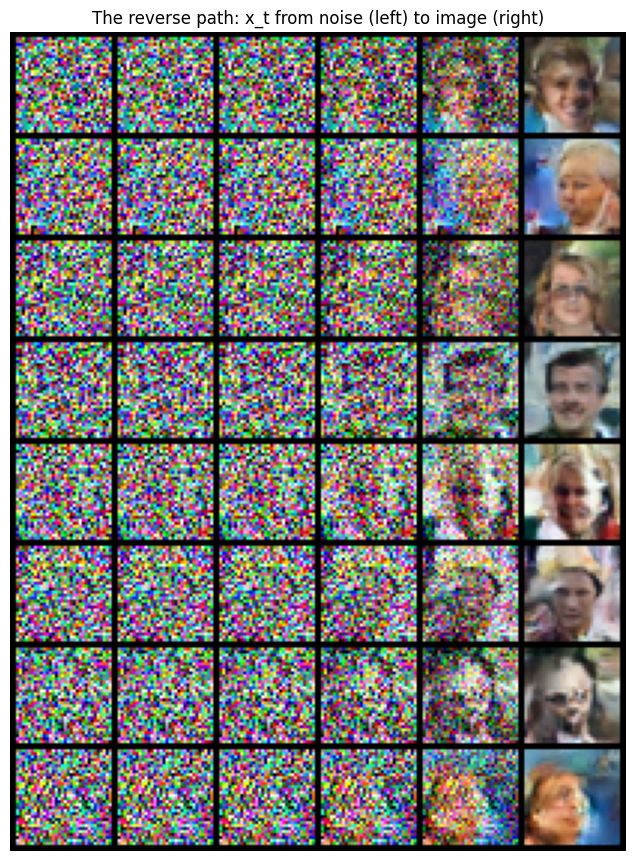

In [8]:
@torch.no_grad()
def sample(model, n=32, steps=SAMPLE_STEPS, ddim=True, xT=None, size=IMAGE_SIZE, keep=()):
    """Denoise from x_T. Returns the images and the intermediate x_t at `keep` indices."""
    model.eval()
    s = DDIMScheduler.from_config(scheduler.config) if ddim else DDPMScheduler.from_config(scheduler.config)
    s.set_timesteps(steps if ddim else scheduler.config.num_train_timesteps)
    x = torch.randn(n, 3, size, size, device=device) if xT is None else xT.to(device)
    trail = []
    for i, t in enumerate(tqdm(s.timesteps, leave=False)):
        with torch.autocast(device, dtype=torch.float16, enabled=device == 'cuda'):
            eps = model(x, t).sample
        x = s.step(eps.float(), t, x).prev_sample
        if i in keep:
            trail.append(x[:8].clone())
    return x, trail

torch.manual_seed(1)
t0 = time.time(); faces_ddim, trail = sample(model, keep=(0, 10, 20, 30, 40, 49)); t_ddim = time.time() - t0
show(faces_ddim, f'From scratch, DDIM {SAMPLE_STEPS} steps ({t_ddim:.1f} s)')
show(torch.stack(trail, 1).flatten(0, 1), 'The reverse path: x_t from noise (left) to image (right)', nrow=len(trail))

  0%|          | 0/1000 [00:00<?, ?it/s]

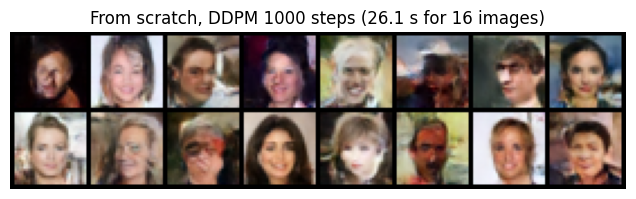

In [9]:
torch.manual_seed(1)
t0 = time.time(); faces_ddpm, _ = sample(model, n=16, ddim=False); t_ddpm = time.time() - t0
show(faces_ddpm, f'From scratch, DDPM 1000 steps ({t_ddpm:.1f} s for 16 images)')

### Question 3

1. How much slower is DDPM than DDIM here? Is the quality visibly better?
2. A GAN generates an image in **one** forward pass. How many U-Net passes
   did one DDIM image cost? What does that mean for a real-time application?

---

# Part 5: Fine-tune a pretrained model

`google/ddpm-cifar10-32` is the DDPM of Ho et al. (2020), trained on
CIFAR-10 — airplanes, cars, animals, never a face. It already knows how to
denoise natural images at 32 × 32. Fine-tune it on the faces, with **half**
the budget the scratch model had, and compare.

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


config.json:   0%|          | 0.00/699 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors: reconstructing file:   0%|          |  0.00B /  143MB            

diffusion_pytorch_model.safetensors: downloading bytes:           |  0.00B            

parameters: 35,746,307


  0%|          | 0/50 [00:00<?, ?it/s]

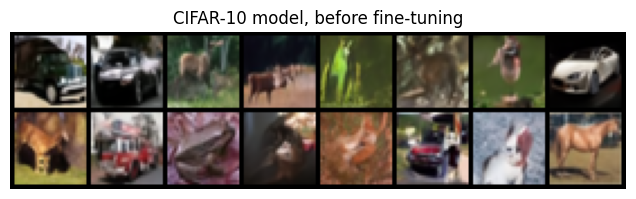

In [10]:
pretrained = UNet2DModel.from_pretrained('google/ddpm-cifar10-32').to(device)
print(f'parameters: {sum(p.numel() for p in pretrained.parameters()):,}')
torch.manual_seed(2)
before, _ = sample(pretrained, n=16)
show(before, 'CIFAR-10 model, before fine-tuning', nrow=8)

  0%|          | 0/1500 [00:00<?, ?it/s]

1500 steps in 15.3 min


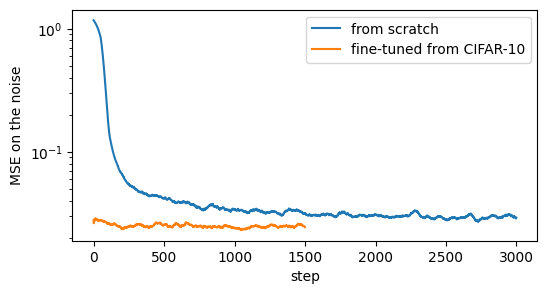

  0%|          | 0/50 [00:00<?, ?it/s]

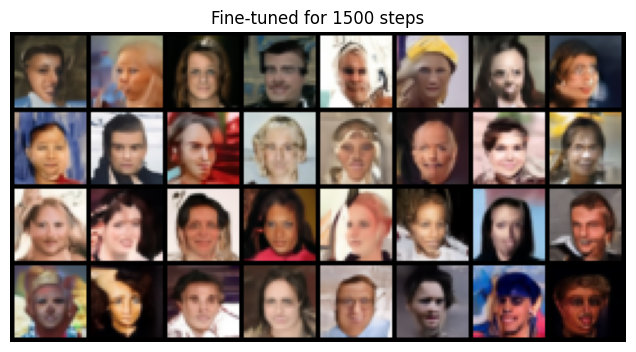

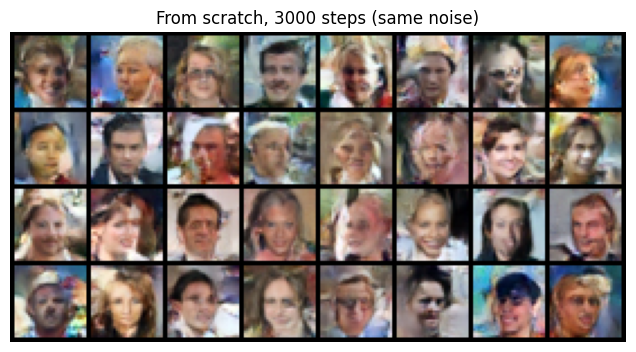

In [11]:
start = time.time()
losses_ft = train(pretrained, FINETUNE_STEPS, lr=5e-5)
print(f'{FINETUNE_STEPS} steps in {(time.time() - start) / 60:.1f} min')

plt.figure(figsize=(6, 3))
plt.plot(smooth(losses_scratch), label='from scratch')
plt.plot(smooth(losses_ft), label='fine-tuned from CIFAR-10')
plt.yscale('log'); plt.xlabel('step'); plt.ylabel('MSE on the noise'); plt.legend(); plt.show()

torch.manual_seed(1)
after, _ = sample(pretrained)
show(after, f'Fine-tuned for {FINETUNE_STEPS} steps')
show(faces_ddim, f'From scratch, {TRAIN_STEPS} steps (same noise)')

### Question 4

1. At equal step count, which loss is lower? Which samples look better?
2. The CIFAR-10 model never saw a face. What did it transfer, then?
   (Session 5's *Transfer Learning* lesson asked the same question for a classifier.)

---

# Part 6: A large pretrained model

`google/ddpm-celebahq-256`: 114M parameters, 256 × 256, trained on
CelebA-HQ for days on TPUs. Same algorithm as yours; more pixels, more
weights, more compute.

model_index.json:   0%|          | 0.00/180 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--google--ddpm-celebahq-256/snapshots/cd5c944777ea2668051904ead6cc120739b86c4d: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--google--ddpm-celebahq-256/snapshots/cd5c944777ea2668051904ead6cc120739b86c4d.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


  0%|          | 0/50 [00:00<?, ?it/s]

44.8 s for 4 images


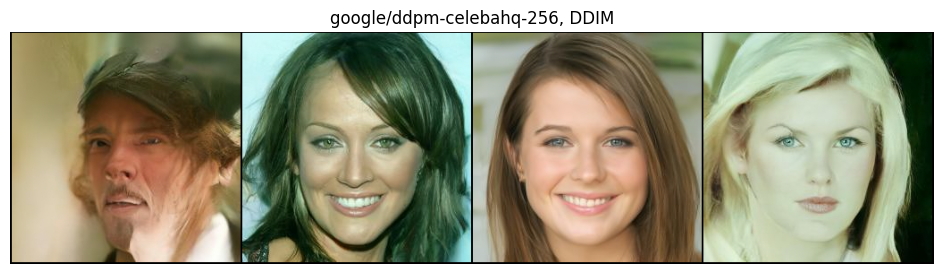

In [12]:
pipe = DDIMPipeline.from_pretrained('google/ddpm-celebahq-256').to(device)
t0 = time.time()
out = pipe(batch_size=4, num_inference_steps=SAMPLE_STEPS, output_type='np',
           generator=torch.Generator(device).manual_seed(0))
print(f'{time.time() - t0:.1f} s for 4 images')
show(torch.tensor(out.images).permute(0, 3, 1, 2) * 2 - 1, 'google/ddpm-celebahq-256, DDIM', nrow=4, size=12)

### Exercise 1: steps against quality

Sample the large model with 10, 25 and 100 DDIM steps (same `generator`
seed). Where does quality stop improving? Time each run.

In [13]:
# TODO: loop over num_inference_steps in [10, 25, 100]; time and show each
for steps in []:  # <-- Modify this!
    pass

---

# Part 7: Interpolating in noise space

DDIM is deterministic: the same $x_T$ always gives the same image, so $x_T$
plays the role of the GAN's latent vector $z$. Gaussian noise lives near a
sphere, so interpolate along it (spherical interpolation), not on a straight line.

  0%|          | 0/50 [00:00<?, ?it/s]

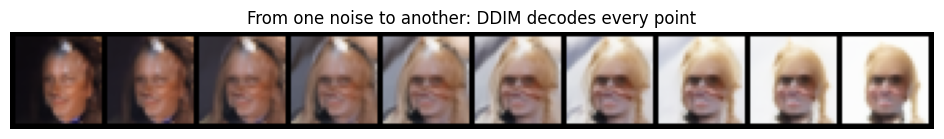

In [14]:
def slerp(a, b, alpha):
    omega = torch.acos(((a * b).sum() / (a.norm() * b.norm())).clamp(-1, 1))
    return (torch.sin((1 - alpha) * omega) * a + torch.sin(alpha * omega) * b) / torch.sin(omega)

torch.manual_seed(3)
a, b = torch.randn(3, IMAGE_SIZE, IMAGE_SIZE), torch.randn(3, IMAGE_SIZE, IMAGE_SIZE)
xT = torch.stack([slerp(a, b, al) for al in torch.linspace(0, 1, 10)])
walk, _ = sample(pretrained, xT=xT)
show(walk, 'From one noise to another: DDIM decodes every point', nrow=10, size=12)

### Exercise 2

Replace `slerp` by the straight line `(1 - alpha) * a + alpha * b`. Look at
the middle images, and compute the norm of the middle noise against the norm
of `a`. Why does the model fail there?

---

## Reflection: GAN or diffusion?

| | DCGAN (other notebook) | DDPM / DDIM (this one) |
|---|---|---|
| training signal | an adversary; two losses that do not say "good" | one regression loss that goes down |
| sampling cost | 1 forward pass | 50 (DDIM) to 1000 (DDPM) passes |
| diversity | prone to mode collapse | covers the data |
| control | a latent vector | the noise, the number of steps, and any conditioning |

1. Fill in, from *your* two runs: training time, sampling time per image, and
   which samples you prefer.
2. Text-to-image models (Stable Diffusion) run this same loop in the latent
   space of an autoencoder, at 64 × 64 latents for 512 × 512 images. Why there,
   and not on pixels?